In [37]:
import json
import pandas as pd
from sklearn.metrics import mean_squared_error as mse
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [38]:
df = pd.read_csv('./lab_2_cybersecurity_intrusion_data.csv')

In [39]:
dff = df.copy()
dff.columns

Index(['Unnamed: 0', 'protocol_type', 'encryption_used', 'network_packet',
       'session_start', 'session_end', 'unusual_time_access', 'login_attempts',
       'failed_logins', 'browser_type', 'ip_reputation_score',
       'attack_detected'],
      dtype='str')

In [40]:
for feature in('encryption_used', 'protocol_type', 'browser_type'):
    dff[feature] = pd.factorize(dff[feature])[0] #encoding the content of those string fields into integer values

In [41]:
dff=dff.drop(columns=['network_packet', 'Unnamed: 0'])

In [42]:
dff['duration'] = dff['session_end'] - dff['session_start']

In [43]:
dff.columns

Index(['protocol_type', 'encryption_used', 'session_start', 'session_end',
       'unusual_time_access', 'login_attempts', 'failed_logins',
       'browser_type', 'ip_reputation_score', 'attack_detected', 'duration'],
      dtype='str')

In [44]:
dff

,protocol_type,encryption_used,session_start,session_end,unusual_time_access,login_attempts,failed_logins,browser_type,ip_reputation_score,attack_detected,duration
0,0,0,1.731193e+09,1.731193e+09,0,4,1,0,0.606818,1,492.983263
1,0,0,1.735516e+09,1.735517e+09,0,3,0,1,0.301569,0,1557.996461
2,0,0,1.739867e+09,1.739867e+09,0,3,2,2,0.739164,1,75.044262
3,1,0,1.738489e+09,1.738489e+09,0,4,0,3,0.123267,1,601.248835
4,0,1,1.736566e+09,1.736566e+09,0,5,1,1,0.054874,0,532.540888
...,...,...,...,...,...,...,...,...,...,...,...
9532,2,1,1.728868e+09,1.728869e+09,0,3,3,2,0.517737,1,226.049889
9533,0,-1,1.735168e+09,1.735168e+09,0,3,0,2,0.408485,0,182.848475
9534,0,1,1.723673e+09,1.723673e+09,0,5,1,1,0.359200,0,35.170249
9535,0,1,1.722477e+09,1.722477e+09,1,4,1,2,0.537417,0,86.664703


In [45]:
X = dff[['protocol_type', 'encryption_used',
       'unusual_time_access', 'login_attempts', 'failed_logins',
       'browser_type', 'ip_reputation_score', 'duration']]
y = dff['attack_detected']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7152, 8), (2385, 8), (7152,), (2385,))

In [47]:
model = DecisionTreeClassifier() # training the model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred.shape)
print(y_pred)

(2385,)
[0 1 1 ... 0 0 1]


In [48]:
print('MSE')
print(f'Train: {mse(y_train, model.predict(X_train))}')
print(f'Test: {mse(y_test, model.predict(X_test))}')

print()

print('R2')
print(f'Train: {model.score(X_train, y_train)}')
print(f'Test: {model.score(X_test, y_test)}')

MSE
Train: 0.0
Test: 0.18742138364779873

R2
Train: 1.0
Test: 0.8125786163522013


In [49]:
models, train_scores, test_scores = [], [], []
for d in tqdm(range(1, model.get_depth() + 1)):
    m = DecisionTreeClassifier(max_depth=d)
    m.fit(X_train, y_train)
    
    train_scores.append(mse(y_train, m.predict(X_train)))
    test_scores.append(mse(y_test, m.predict(X_test)))
    models.append(m)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:01<00:00, 36.45it/s]


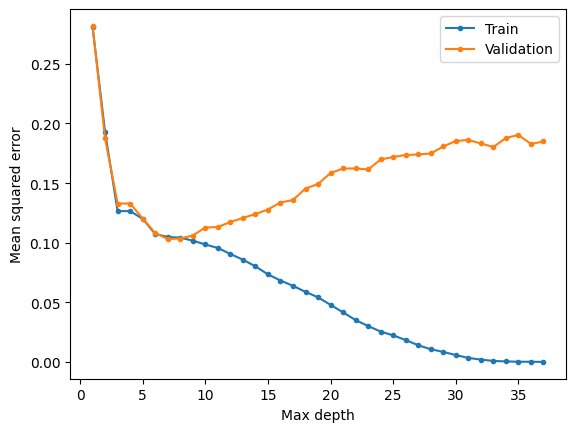

In [50]:
plt.plot(np.arange(model.get_depth()) + 1, train_scores, marker='.', label='Train')
plt.plot(np.arange(model.get_depth()) + 1, test_scores, marker='.', label="Validation")
plt.gca().set_xlabel('Max depth')
plt.gca().set_ylabel('Mean squared error')
plt.legend();

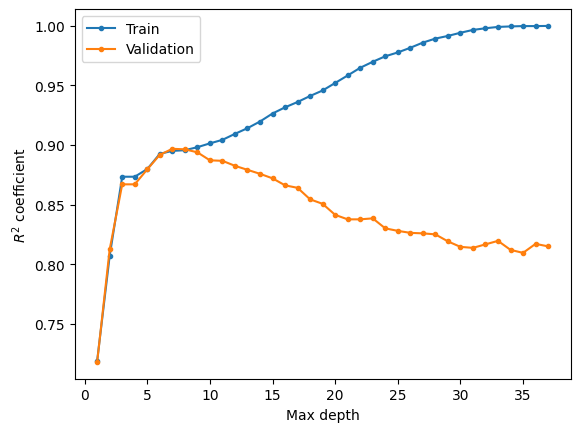

In [51]:
plt.plot(np.arange(model.get_depth()) + 1, [m.score(X_train, y_train) for m in models], marker='.', label='Train')
plt.plot(np.arange(model.get_depth()) + 1, [m.score(X_test, y_test) for m in models], marker='.', label='Validation')
plt.gca().set_xlabel('Max depth')
plt.gca().set_ylabel('$R^2$ coefficient')
plt.legend();

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
rf = RandomForestClassifier(oob_score=True)
rf.fit(X_train, y_train)

print(f'Train: {rf.score(X_train, y_train)}')
print(f'Validation: {rf.score(X_test, y_test)}')
print(f'OOB: {rf.oob_score_}')

Train: 1.0
Validation: 0.889308176100629
OOB: 0.8860458612975392


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:03<00:00,  8.09it/s]


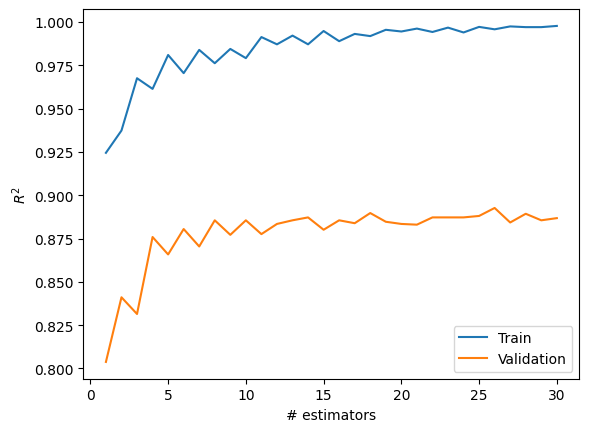

In [54]:
trn, val, oob = [], [], []
for n in tqdm(1 + np.arange(30)):
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)
    trn.append(rf.score(X_train, y_train))
    val.append(rf.score(X_test, y_test))
    
plt.plot(1 + np.arange(30), trn, label='Train')
plt.plot(1 + np.arange(30), val, label='Validation')
plt.gca().set_xlabel('# estimators')
plt.gca().set_ylabel('$R^2$')
plt.legend()
plt.show()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:02<00:00,  6.57it/s]


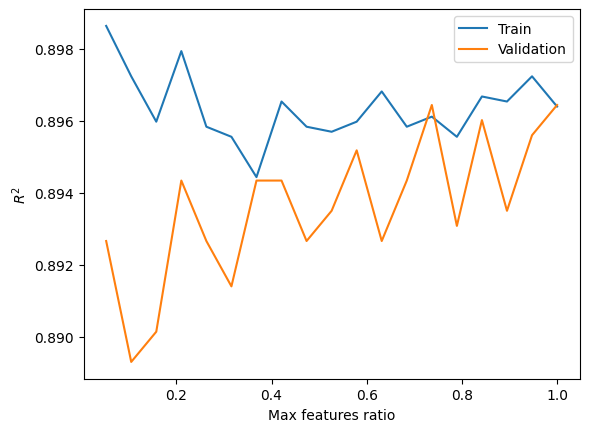

In [55]:
trn, val = [], []
x = np.linspace(0, 1, 20)[1:]
for mf in tqdm(x):
    rf = RandomForestClassifier(n_estimators=20, max_features=mf, max_depth=10)
    rf.fit(X_train, y_train)
    
    trn.append(rf.score(X_train, y_train))
    val.append(rf.score(X_test, y_test))
    
plt.plot(x, trn, label='Train')
plt.plot(x, val, label='Validation')
plt.gca().set_xlabel('Max features ratio')
plt.gca().set_ylabel('$R^2$')
plt.legend();